# Important Note
This file is for demonstration purposes only.
Please note that this notebook is currently not executable, as the `Explainer` and `ChangepointDetector` classes are __not yet published__.

The goal of this notebook is to illustrate how the framework simplifies the workflow compared to coding everything from scratch. It is subject to change in future updates.

In [1]:
import numpy as np
from sklearn.datasets import fetch_openml

from dragon.detectors.Simple_CPD import Simple_CPD # not published yet
from dragon.util.Stream import Stream, induce_drift_from_data
from dragon.explanations import TSNEExplainer, CounterfactualExplainer # not published yet
from dragon.detectors import MMD
from dragon.stream.Structure import Pipeline
from dragon.stream.SlidingWindow import SlidingWindow

In [2]:
print('Downloading the dataset...')
mnist = fetch_openml('Fashion-MNIST')  #, parser='auto')
print('Download complete.')

labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Store the dataset in an appropriate format
# since dragon needs a flat array, the data is normalized here
X = mnist.data.values.astype('float32') / 255.0
y = np.array(mnist.target).astype(int)

Download complete.


## Preparing the data for the distribution shift analysis

In this part, we prepare the Fashion-MNIST dataset for the distribution shift analysis. We map each digit in the dataset to a label indicating whether it occurs before or after the change point, or both, or neither. We then remove the samples with label 0 (i.e., pieces that do not occur before nor after the change point) from the input features and labels. Finally, we randomly assign labels of 1 or 2 to samples with label 3 (i.e., pieces that occur both before and after the change point). This ensures that we have a balanced dataset with labels 1 and 2 representing the digits that occur before and after the change point, respectively.

Note: This whole processing step is done in the induce_drift_from_data method.

In [3]:
test_data = induce_drift_from_data(X=X, y=y,
                                   classes_before_drift=[0, 1],
                                   classes_after_drift=[2, 3],
                                   shared_classes=[7, 9],
                                   samples_per_concept=[1000, 1000]
                                   )

Starting stream...
Computing Random Forest kernel matrix...
Computing complete.
Computing eigenvalues and eigenvectors...
Computing eigenvalues and eigenvectors complete.
Fitting t-SNE model...
Fitting complete.


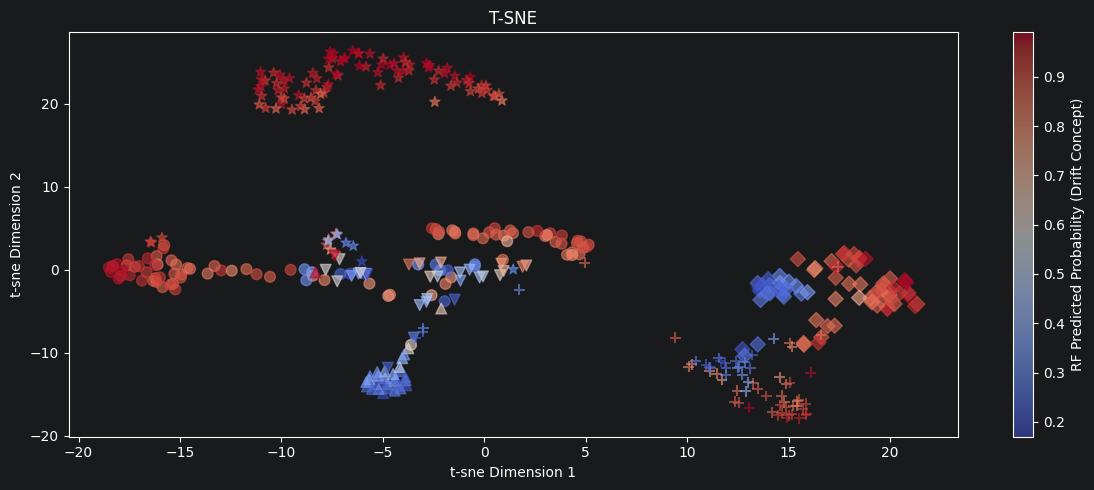

Computing Random Forest kernel matrix...
Computing complete.
Computing eigenvalues and eigenvectors...
Computing eigenvalues and eigenvectors complete.


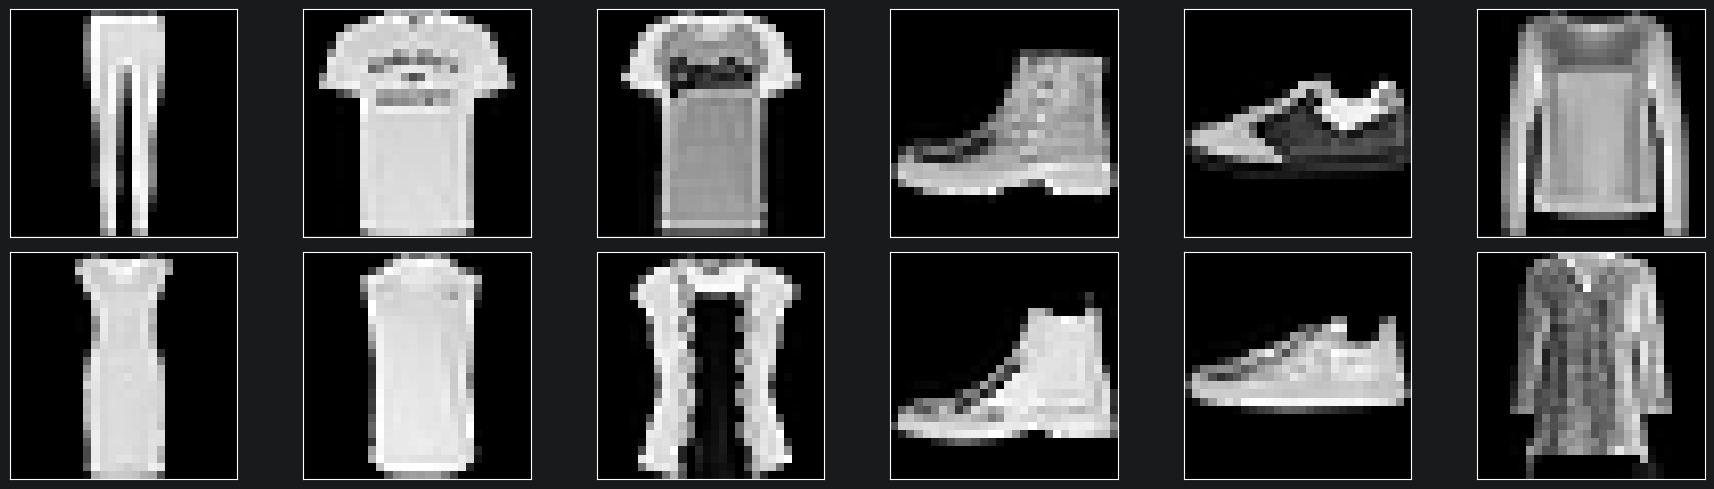

Computing Random Forest kernel matrix...
Computing complete.
Computing eigenvalues and eigenvectors...
Computing eigenvalues and eigenvectors complete.
Fitting t-SNE model...
Fitting complete.


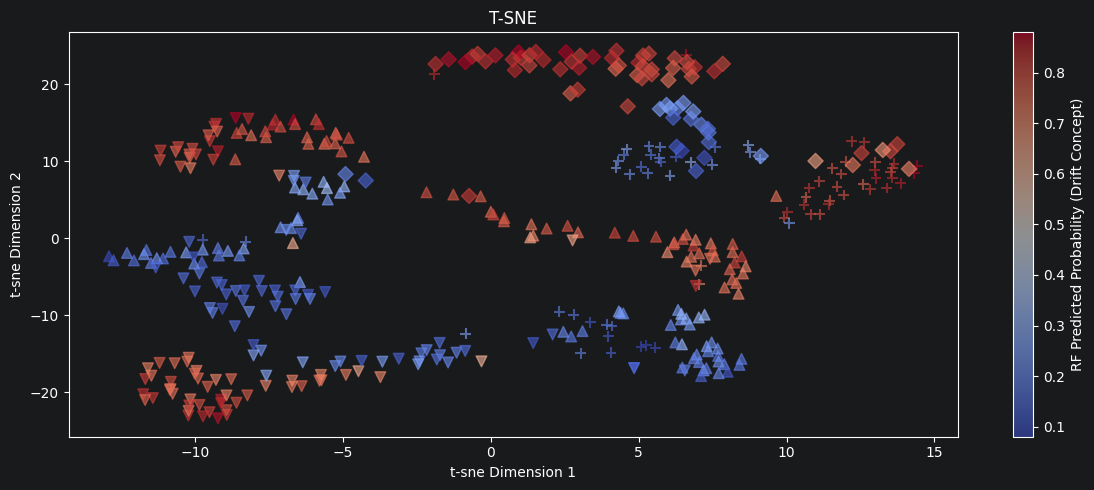

Computing Random Forest kernel matrix...
Computing complete.
Computing eigenvalues and eigenvectors...
Computing eigenvalues and eigenvectors complete.


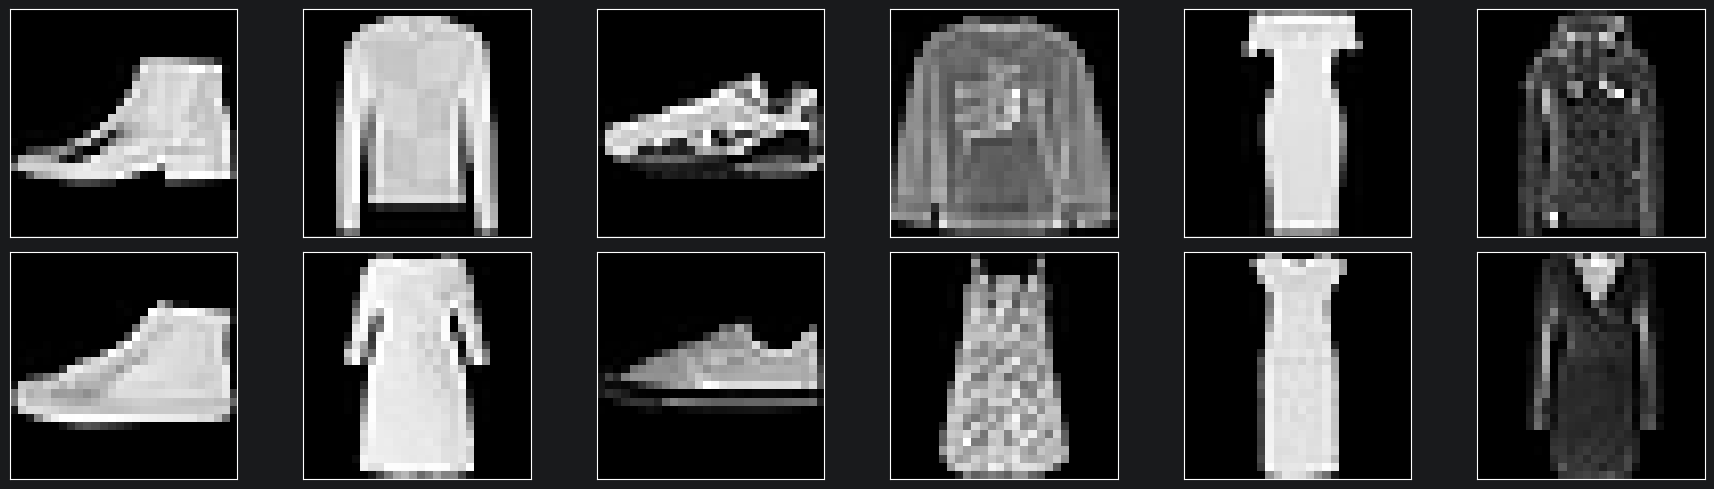


--- [Data stream finished: EVENT] ---
Processed 2000 samples.

--- [Data stream finished: EVENT] ---
Processed 2000 samples.


,event_metric,event_p_value,event_detector_name,event_detector_time,event_window,event_trigger_score,event_split_indices,tsne_embedding,probs,y_true
0,changepoint,0.0,Simple_CPD,0,[SlidingWindow 'max_size': 200],0.003763,[274],"[[15.858965, -17.491194], [-8.451322, 23.72130...","[0.93, 0.98, 0.83, 0.89, 0.9, 0.89, 0.95, 0.97...","[9, 1, 7, 0, 0, 1, 1, 1, 0, 1, 7, 0, 0, 7, 0, ..."
1,changepoint,0.0,Simple_CPD,0,[SlidingWindow 'max_size': 200],0.004537,[222],"[[6.6903872, 21.950565], [-7.388844, 14.741896...","[0.89, 0.9, 0.69, 0.81, 0.94, 0.79, 0.78, 0.75...","[7, 2, 3, 9, 7, 3, 3, 2, 9, 3, 3, 7, 7, 3, 7, ..."


In [4]:
w_size = 200
sw_new = SlidingWindow(max_size=w_size)
sw_old = SlidingWindow(max_size=w_size)

pipe = Pipeline(sw_old, sw_new)

stream = Stream(test_data)
stream.add_listener(pipe)

mmd = MMD(sw_old, sw_new, threshold=0.01)
cp_detector = Simple_CPD(windows=[sw_old, sw_new], target=mmd, target_window=sw_new, min_cp=1, max_cp=2, n_cv=5)

sources = {sw_old: 0, sw_new: 1}

markers = ["o", "*", "^", "v", "X", "P", "s", "D", "h", "+"]
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

tsne_explainer = TSNEExplainer(
    data_sources=sources,
    detector=cp_detector,
    class_names=class_names,
    markers=markers)

stream.add_listener(tsne_explainer)

counterfactual_explainer = CounterfactualExplainer(
    data_sources=sources,
    detector=cp_detector)
stream.add_listener(counterfactual_explainer)
print("Starting stream...")
stream.run()

display(tsne_explainer.get_results_df())